In [3]:
import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.losses import MeanSquaredError

sys.path.insert(0, "../../")
from config import DATASETS_PATH, MODELS_PATH, IMG_SHAPE, SEED

In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 1. Manually Collect File Paths and Labels ---
IMAGES_TEST_PATH = os.path.join(DATASETS_PATH, 'cropped', 'vae', 'test')
BATCH_SIZE = 64

print("Manually collecting labeled file paths and labels...")
labeled_file_paths = []
labeled_labels = []
class_names = sorted([d for d in os.listdir(IMAGES_TEST_PATH) if os.path.isdir(os.path.join(IMAGES_TEST_PATH, d))])
class_map = {name: i for i, name in enumerate(class_names)}
print(class_map)
for class_name in class_names:
    class_dir = os.path.join(IMAGES_TEST_PATH, class_name)
    for filepath in os.listdir(class_dir):
        labeled_file_paths.append(os.path.join(class_dir, filepath))
        labeled_labels.append(class_map[class_name])

# Convert to NumPy arrays for scikit-learn
labeled_file_paths = np.array(labeled_file_paths)
labeled_labels = np.array(labeled_labels)
print(f"Found {len(labeled_file_paths)} labeled images belonging to {len(class_names)} classes.")


# --- 2. Perform a Stratified Split ---

print("Performing stratified split...")
_, test_files, _, test_labels = train_test_split(
    labeled_file_paths,
    labeled_labels,
    test_size=0.9,
    stratify=labeled_labels, # This ensures the split is balanced!
    random_state=42
)

# --- 3. Create tf.data.Dataset Objects ---

def load_and_normalize(path, label):
    """Reads image from path, preprocesses it, and passes label through."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, IMG_SHAPE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create the test dataset for final evaluation
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_ds = test_ds.map(load_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Manually collecting labeled file paths and labels...
{'anaphase': 0, 'metaphase': 1, 'prophase': 2, 'telophase': 3}
Found 242 labeled images belonging to 4 classes.
Performing stratified split...


I0000 00:00:1760034645.425441    6687 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21364 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
# A custom layer to sample from the latent space
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# (This code assumes you have a trained 'vae' model and a labeled 'test_dataset')
# The test_dataset should yield (image, label) tuples.

# --- 1. Calculate Latent Space Centroids for Each Class ---
print("Calculating latent space centroids...")

custom_objects = {"Sampling": Sampling}
encoder = tf.keras.models.load_model(os.path.join(MODELS_PATH, 'vae', 'm1_encoder_mitosis_canny2.keras'), custom_objects=custom_objects)

all_z_mean = []
all_labels = []

# Pass the entire test set through the encoder
for images, labels in test_ds:
    z_mean, _, _ = encoder.predict(images, verbose=0)
    all_z_mean.append(z_mean)
    all_labels.append(labels.numpy())

all_z_mean = np.concatenate(all_z_mean, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Calculate the average latent vector for each class
num_classes = 4 # You have 4 classes
latent_dim = all_z_mean.shape[1]
class_centroids = {}
for i in range(num_classes):
    class_vectors = all_z_mean[all_labels == i]
    class_centroids[i] = np.mean(class_vectors, axis=0)

print("Centroids calculated.")

Calculating latent space centroids...


2025-10-09 15:30:57.519928: I external/local_xla/xla/service/service.cc:163] XLA service 0x72f9ec009aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-09 15:30:57.519939: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-10-09 15:30:57.529032: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-09 15:30:57.557997: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
2025-10-09 15:30:57.571046: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-09 15:30:57.826117: I e

Centroids calculated.


2025-10-09 15:30:59.556164: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saving generated images to '/home/nicolas/Documentos/UTN/INA/giar_ina_dev/datasets/cropped/generated/vae2/' directory...


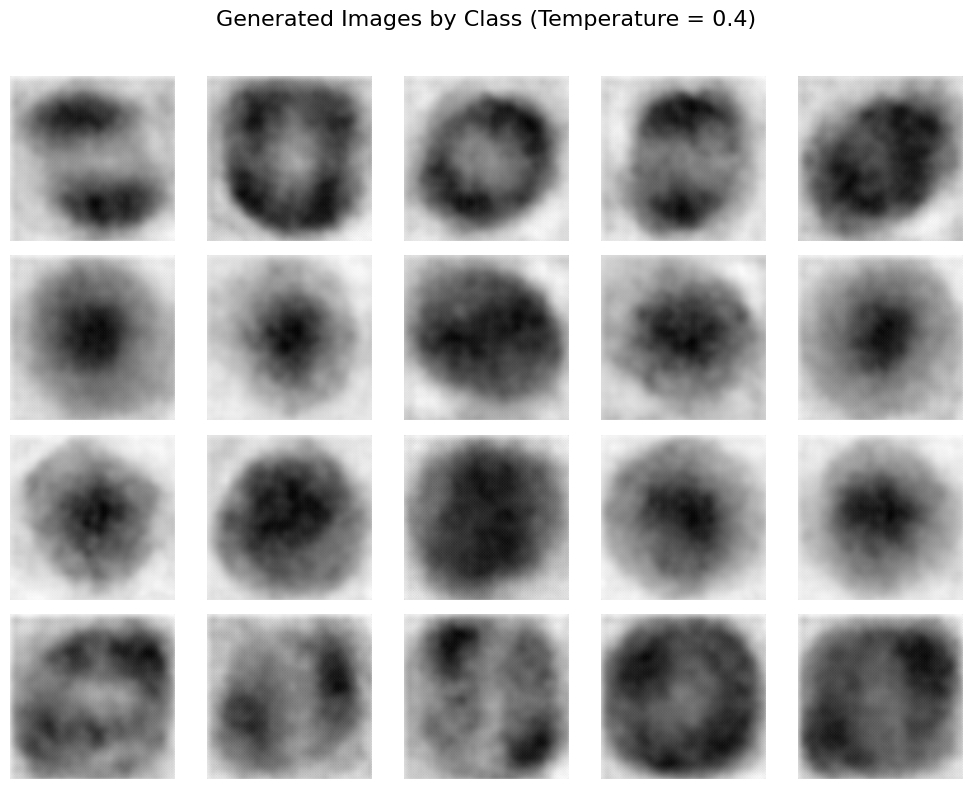

Done.


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

# --- NEW: Helper function for contrast stretching ---
def stretch_histogram(image_np):
    """Stretches the contrast of a float image in the [0,1] range."""
    min_val = np.min(image_np)
    max_val = np.max(image_np)
    if max_val - min_val > 1e-6: # Avoid division by zero for blank images
        return (image_np - min_val) / (max_val - min_val)
    return image_np

# --- Configuration ---
# (Your configuration code is the same)
decoder = tf.keras.models.load_model(os.path.join(MODELS_PATH, 'vae', 'm1_decoder_mitosis_canny.keras'))
temperature = 0.4
num_samples_per_class = 5
OUTPUT_DIR = os.path.join(DATASETS_PATH, 'cropped', 'generated', 'vae2')
class_names =['anaphase', 'metaphase', 'prophase', 'telophase']
num_classes = len(class_names) # Define num_classes

# --- Generate and Plot Images ---
# (The setup code is the same)
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 2 * num_classes))
fig.suptitle(f'Generated Images by Class (Temperature = {temperature})', fontsize=16)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Saving generated images to '{OUTPUT_DIR}/' directory...")

# Loop through each class using its name and index
for i, class_name in enumerate(class_names):
    axes[i, 0].set_ylabel(f'Class "{class_name}"', rotation=0, size='large', labelpad=60)
    class_dir = os.path.join(OUTPUT_DIR, class_name)
    os.makedirs(class_dir, exist_ok=True)

    if i in class_centroids:
        for j in range(num_samples_per_class):
            centroid = class_centroids[i]
            epsilon = np.random.normal(size=centroid.shape)
            z_sample = centroid + temperature * epsilon
            z_sample = np.expand_dims(z_sample, axis=0)
            
            generated_image = decoder.predict(z_sample, verbose=0)[0]
            
            # Plot the image (imshow auto-stretches the contrast)
            ax = axes[i, j]
            ax.imshow(generated_image.squeeze(), cmap='gray')
            ax.axis('off')
            
            # --- CORRECTED SAVING LOGIC ---
            # 1. Manually stretch the contrast of the generated image
            stretched_image = stretch_histogram(generated_image)
            
            # 2. Convert the STRETCHED image to uint8 [0, 255] for saving
            image_to_save = (stretched_image * 255).astype(np.uint8)
            
            # 3. Define filename and save the high-contrast image
            filename = f"{class_name}_sample_{j+1}.png"
            filepath = os.path.join(class_dir, filename)
            cv2.imwrite(filepath, image_to_save)
            # --- END CORRECTION ---
    else:
        for j in range(num_samples_per_class):
            axes[i, j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
print("Done.")

In [6]:
import tensorflow as tf
import numpy as np
import os
import cv2
from tqdm import tqdm # Import tqdm for the progress bar

# --- Helper function for contrast stretching ---
def stretch_histogram(image_np):
    """Stretches the contrast of a float image in the [0,1] range."""
    min_val = np.min(image_np)
    max_val = np.max(image_np)
    if max_val - min_val > 1e-6:
        return (image_np - min_val) / (max_val - min_val)
    return image_np

# --- Configuration ---
# (Assuming vae, test_ds, and class_centroids are available from previous steps)
decoder = tf.keras.models.load_model(os.path.join(MODELS_PATH, 'vae', 'm1_decoder_mitosis_canny.keras'))
temperature = 0.4
num_samples_per_class = 1000 # <-- SET YOUR DESIRED NUMBER HERE
OUTPUT_DIR = os.path.join(DATASETS_PATH, 'cropped', 'generated', 'vae2')
class_names =['anaphase', 'metaphase', 'prophase', 'telophase']
latent_dim = encoder.output[0].shape[-1] # Get latent dim from the model

# --- Generate and Save Images ---
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Generating {num_samples_per_class} images per class...")

# Loop through each class
for i, class_name in enumerate(class_names):
    print(f"\nGenerating images for class: '{class_name}'")
    class_dir = os.path.join(OUTPUT_DIR, class_name)
    os.makedirs(class_dir, exist_ok=True)

    if i in class_centroids:
        # Use tqdm for a progress bar
        for j in tqdm(range(num_samples_per_class)):
            centroid = class_centroids[i]
            
            # Create a new sample
            epsilon = np.random.normal(size=centroid.shape)
            z_sample = centroid + temperature * epsilon
            z_sample = np.expand_dims(z_sample, axis=0)
            
            # Generate the image
            generated_image = decoder.predict(z_sample, verbose=0)[0]
            
            # Manually stretch the contrast
            stretched_image = stretch_histogram(generated_image)
            
            # Convert to uint8 [0, 255] for saving
            image_to_save = (stretched_image * 255).astype(np.uint8)
            
            # Define filename and save the image
            filename = f"{class_name}_sample_{j+1:04d}.png" # Add padding to filename
            filepath = os.path.join(class_dir, filename)
            cv2.imwrite(filepath, image_to_save)

print("\nDone.")

Generating 1000 images per class...

Generating images for class: 'anaphase'


100%|██████████| 1000/1000 [00:35<00:00, 28.49it/s]



Generating images for class: 'metaphase'


100%|██████████| 1000/1000 [00:34<00:00, 29.02it/s]



Generating images for class: 'prophase'


100%|██████████| 1000/1000 [00:34<00:00, 28.92it/s]



Generating images for class: 'telophase'


100%|██████████| 1000/1000 [00:34<00:00, 28.83it/s]


Done.


In [4]:
import torch
import os
import glob # For listing files
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
from diffusers.utils import load_image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# --- 0. Global Configuration (Set your paths here) ---
MODELS_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/models" # Base path for your models
OUTPUT_GENERATED_PATH = os.path.join(DATASETS_PATH, 'cropped', 'generated', 'diffuser2') # New path for generated images

# Specify your trained ControlNet model directory
CONTROLNET_MODEL_NAME = "controlnet_2" # Name of the folder containing your trained ControlNet
CONTROLNET_PATH = os.path.join(MODELS_PATH, CONTROLNET_MODEL_NAME)

# Specify the base Stable Diffusion model (the one your ControlNet was trained on)
# Make sure this matches the PRETRAINED_MODEL you used for training your ControlNet
PRETRAINED_MODEL = "runwayml/stable-diffusion-v1-5" # Or "SG161222/Realistic_Vision_V5_1_noVAE" if that's what you trained with

# Input directory where your blurry images are organized by class
# Assuming structure: INPUT_BLURRY_BASE_PATH/class_name/image.png
INPUT_BLURRY_BASE_PATH = os.path.join(DATASETS_PATH, 'cropped', 'generated', 'vae2')
# Example: /home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/controlnet_dataset/train/blurred_upscaled_classes/prophase/image.png

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_RESOLUTION = 512 # The resolution you trained on

# Define a common negative prompt
NEGATIVE_PROMPT = "blurry, low quality, bad, deformed, malformed, text, watermark, jpeg artifacts, incorrect cell phase"

In [5]:
# --- Create the output base directory if it doesn't exist ---
os.makedirs(OUTPUT_GENERATED_PATH, exist_ok=True)
print(f"Output directory for generated images: {OUTPUT_GENERATED_PATH}")

# --- Load the ControlNet adapter ---
print(f"Loading ControlNet from: {CONTROLNET_PATH}")
controlnet = ControlNetModel.from_pretrained(CONTROLNET_PATH, torch_dtype=torch.float16)

# --- Load the full pipeline ---
print(f"Loading base Stable Diffusion pipeline: {PRETRAINED_MODEL}")
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    PRETRAINED_MODEL,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None # Keep safety_checker=None if you explicitly want it off
).to(DEVICE)

# --- Optimize the scheduler ---
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

print("✅ Pipeline loaded successfully!")

Output directory for generated images: /home/nicolas/Documentos/UTN/INA/giar_ina_dev/datasets/cropped/generated/diffuser2
Loading ControlNet from: /home/nicolas/Documentos/UTN/INA/giar_ina_dev/models/controlnet_2
Loading base Stable Diffusion pipeline: runwayml/stable-diffusion-v1-5


Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.33it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ Pipeline loaded successfully!


In [6]:
# --- 1. Identify Class Directories and Prepare Prompts ---
# Get a list of all subdirectories (class names) in your input blurry path
class_dirs = [d for d in os.listdir(INPUT_BLURRY_BASE_PATH) if os.path.isdir(os.path.join(INPUT_BLURRY_BASE_PATH, d))]
class_dirs.sort() # Ensure consistent order

if not class_dirs:
    print(f"No class directories found in {INPUT_BLURRY_BASE_PATH}. Please check your path.")
    exit()

print(f"\nFound {len(class_dirs)} classes: {', '.join(class_dirs)}")

# We'll collect a few samples for display later
sample_control_images_display = []
sample_generated_images_display = []
sample_prompts_for_display = []
SAMPLE_COUNT_PER_CLASS = 1 # How many images per class to display (e.g., 1 or 2)

# --- 2. Loop through each class and its images ---
print("\nStarting image generation for all classes...")
total_images_processed = 0

for class_name in class_dirs:
    print(f"\n--- Processing class: {class_name} ---")

    # Construct the generic prompt for this class
    # You can adjust this prompt generation logic if your class names don't directly map to the desired prompt
    # Example: "prophase" -> "micrograph of cell in prophase"
    current_prompt = f"micrograph of cell in {class_name}"

    # Create the output directory for this class
    output_class_dir = os.path.join(OUTPUT_GENERATED_PATH, class_name)
    os.makedirs(output_class_dir, exist_ok=True)

    # Get all blurry image paths for the current class
    blurry_image_paths = glob.glob(os.path.join(INPUT_BLURRY_BASE_PATH, class_name, "*.png"))
    blurry_image_paths.sort() # Ensure consistent order for reproducibility

    if not blurry_image_paths:
        print(f"  No blurry images found in {os.path.join(INPUT_BLURRY_BASE_PATH, class_name)}. Skipping class.")
        continue

    print(f"  Found {len(blurry_image_paths)} images in '{class_name}'.")

    # Generate images for this class
    images_generated_this_class = 0
    for i, img_path in enumerate(blurry_image_paths):
        # Optional: Print progress every X images
        if (i + 1) % 10 == 0 or i == 0 or (i + 1) == len(blurry_image_paths):
            print(f"    Generating image {i+1}/{len(blurry_image_paths)} for '{class_name}'...")

        # Load the image and resize it to the resolution you trained on (512x512)
        control_image = load_image(img_path).resize((IMAGE_RESOLUTION, IMAGE_RESOLUTION))

        # Use a unique seed for each image, good for variety but can be fixed for exact comparison
        # Using a combination of a base seed and image index
        generator = torch.manual_seed(42 + total_images_processed + i)

        # Run the pipeline!
        with torch.no_grad(): # No need for gradients during inference
            output_image = pipe(
                current_prompt,
                negative_prompt=NEGATIVE_PROMPT,
                image=control_image,
                num_inference_steps=25, # A good value for UniPCMultistepScheduler
                generator=generator,
            ).images[0]

        # Save the generated image
        image_filename = os.path.basename(img_path)
        output_image_path = os.path.join(output_class_dir, f"sharp_{image_filename}")
        output_image = output_image.resize(IMG_SHAPE)
        output_image.save(output_image_path)
        images_generated_this_class += 1
        total_images_processed += 1

        # Collect samples for display
        if images_generated_this_class <= SAMPLE_COUNT_PER_CLASS:
            sample_control_images_display.append(control_image)
            sample_generated_images_display.append(output_image)
            sample_prompts_for_display.append(f"Class: {class_name}\nPrompt: '{current_prompt}'")

    print(f"  ✅ Finished generating {images_generated_this_class} images for class '{class_name}'.")

print(f"\n--- Generation complete. Total images processed: {total_images_processed} ---")


Found 4 classes: anaphase, metaphase, prophase, telophase

Starting image generation for all classes...

--- Processing class: anaphase ---
  Found 1000 images in 'anaphase'.
    Generating image 1/1000 for 'anaphase'...


100%|██████████| 25/25 [00:01<00:00, 14.46it/s]


    Generating image 10/1000 for 'anaphase'...


100%|██████████| 25/25 [00:01<00:00, 15.26it/s]


    Generating image 20/1000 for 'anaphase'...


...

    Generating image 990/1000 for 'telophase'...


100%|██████████| 25/25 [00:01<00:00, 15.97it/s]


    Generating image 1000/1000 for 'telophase'...


100%|██████████| 25/25 [00:01<00:00, 16.02it/s]


  ✅ Finished generating 1000 images for class 'telophase'.

--- Generation complete. Total images processed: 4000 ---
